✅ Libraries imported successfully
✅ Dataset loaded successfully!
   Shape: 1,067,371 rows × 8 columns

📋 Columns in dataset:
   1. 'Invoice'
   2. 'StockCode'
   3. 'Description'
   4. 'Quantity'
   5. 'InvoiceDate'
   6. 'Price'
   7. 'Customer ID'
   8. 'Country'
✅ Standardized column names:
   ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

📋 First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom



📊 Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   UnitPrice    1067371 non-null  float64
 6   CustomerID   824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None

📊 Statistical Summary:


,Quantity,UnitPrice,CustomerID
count,1067371.00,1067371.00,824364.00
mean,9.94,4.65,15324.64
std,172.71,123.55,1697.46
min,-80995.00,-53594.36,12346.00
25%,1.00,1.25,13975.00
50%,3.00,2.10,15255.00
75%,10.00,4.15,16797.00
max,80995.00,38970.00,18287.00



🔍 Missing Values Analysis:
--------------------------------------------------


,Column,Missing_Values,Missing_Percentage
6,CustomerID,243007,22.77
2,Description,4382,0.41



🧹 Starting data cleaning...
   ✓ Removed 243,007 rows with missing CustomerID
   ✓ Removed 18,744 invalid quantities
   ✓ Removed 71 invalid prices

   ✅ Cleaning completed!
      Original: 1,067,371 rows
      Final: 805,549 rows
      Removed: 261,822 rows (24.5%)

✅ Cleaned data info:
   Total records: 805,549
   Unique customers: 5,878
   Unique products: 4,631
   Countries: 41
   Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

📊 Outlier Visualization - Quantity:


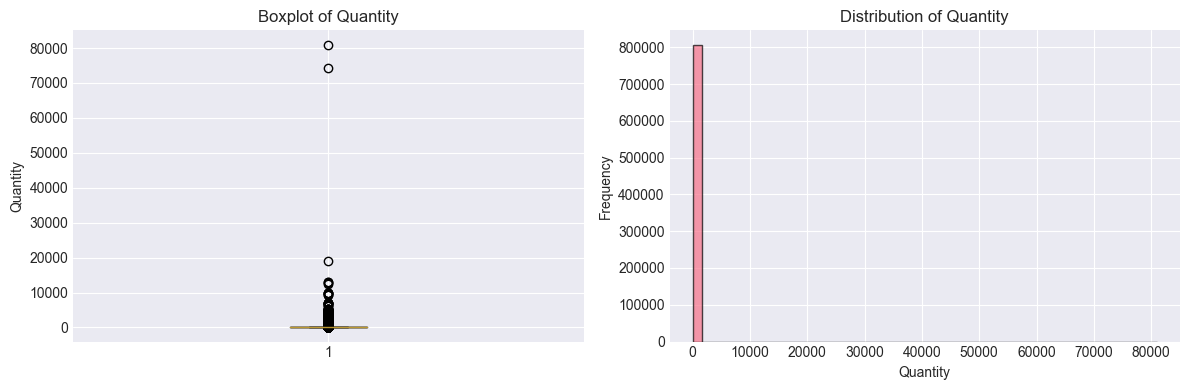


📊 Outlier Visualization - UnitPrice:


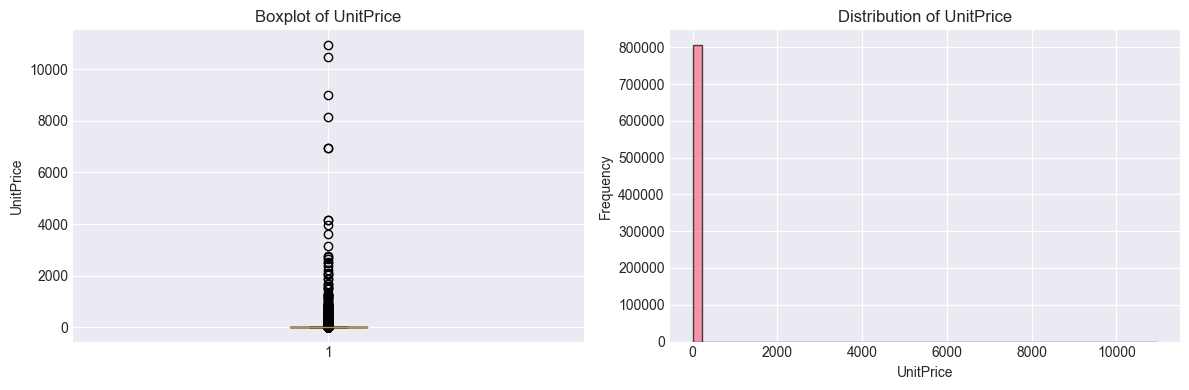


📌 Quantity:
   Outliers capped: 51,983 (6.5%)

📌 UnitPrice:
   Outliers capped: 67,346 (8.4%)
✅ Cleaned data saved to: ../data/processed/cleaned_data.csv

📋 Final Data Summary:
   Total revenue: £17,743,429.18
   Average transaction value: £22.03

📊 SUMMARY STATISTICS


,Metric,Value
0,Total Records,"805,549"
1,Unique Customers,"5,878"
2,Unique Products,"4,631"
3,Total Countries,41



✅ Data preprocessing completed successfully!


In [2]:
# %% [markdown]
# # 📊 01 - Data Preprocessing
# ## Customer Segmentation Project

# %% [markdown]
# ### Import Libraries

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully")

# %% [markdown]
# ### Load Dataset

# %%
# Load the dataset
data_path = '../data/raw/online_retail_II.csv'

try:
    df = pd.read_csv(data_path, encoding='latin1')
    print(f"✅ Dataset loaded successfully!")
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"\n📋 Columns in dataset:")
    for i, col in enumerate(df.columns, 1):
        print(f"   {i}. '{col}'")
except FileNotFoundError:
    print("❌ Dataset not found! Please download and place in: data/raw/online_retail_II.csv")
    print("Download from: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci")

# %% [markdown]
# ### Standardize Column Names

# %%
# Standardize column names (remove spaces and standardize)
df.columns = df.columns.str.strip()

# Create mapping dictionary
column_mapping = {}
for col in df.columns:
    col_lower = col.lower().replace(' ', '_').replace('-', '_')
    
    if 'customer' in col_lower and ('id' in col_lower or 'code' in col_lower):
        column_mapping[col] = 'CustomerID'
    elif 'invoice' in col_lower and 'no' in col_lower:
        column_mapping[col] = 'InvoiceNo'
    elif 'invoice' in col_lower and 'date' in col_lower:
        column_mapping[col] = 'InvoiceDate'
    elif 'stock' in col_lower or 'product' in col_lower or 'code' in col_lower:
        column_mapping[col] = 'StockCode'
    elif 'description' in col_lower:
        column_mapping[col] = 'Description'
    elif 'quantity' in col_lower:
        column_mapping[col] = 'Quantity'
    elif 'unit' in col_lower and 'price' in col_lower:
        column_mapping[col] = 'UnitPrice'
    elif 'price' in col_lower:
        column_mapping[col] = 'UnitPrice'
    elif 'country' in col_lower:
        column_mapping[col] = 'Country'

# Rename columns
df.rename(columns=column_mapping, inplace=True)

print("✅ Standardized column names:")
print(f"   {list(df.columns)}")

# %% [markdown]
# ### Initial Data Exploration

# %%
# First few rows
print("\n📋 First 5 rows:")
display(df.head())

# Data info
print("\n📊 Data Information:")
print(df.info())

# Statistical summary
print("\n📊 Statistical Summary:")
display(df.describe())

# %% [markdown]
# ### Check Missing Values

# %%
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Values': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).values
}).sort_values('Missing_Values', ascending=False)

print("\n🔍 Missing Values Analysis:")
print("-" * 50)
display(missing_df[missing_df['Missing_Values'] > 0])

# %% [markdown]
# ### Data Cleaning

# %%
def clean_data(df):
    """Clean the raw transaction data"""
    print("\n🧹 Starting data cleaning...")
    original_shape = df.shape
    
    # Make a copy
    df_clean = df.copy()
    
    # Step 1: Remove rows with missing CustomerID
    if 'CustomerID' in df_clean.columns:
        missing_customers = df_clean['CustomerID'].isnull().sum()
        df_clean = df_clean.dropna(subset=['CustomerID'])
        print(f"   ✓ Removed {missing_customers:,} rows with missing CustomerID")
    else:
        print("   ⚠️ CustomerID column not found!")
    
    # Step 2: Remove cancelled orders (invoices starting with 'C')
    if 'InvoiceNo' in df_clean.columns:
        cancelled = df_clean['InvoiceNo'].astype(str).str.startswith('C')
        cancelled_count = cancelled.sum()
        df_clean = df_clean[~cancelled]
        print(f"   ✓ Removed {cancelled_count:,} cancelled transactions")
    
    # Step 3: Remove invalid quantities and prices
    if 'Quantity' in df_clean.columns:
        invalid_qty = (df_clean['Quantity'] <= 0).sum()
        df_clean = df_clean[df_clean['Quantity'] > 0]
        print(f"   ✓ Removed {invalid_qty:,} invalid quantities")
    
    if 'UnitPrice' in df_clean.columns:
        invalid_price = (df_clean['UnitPrice'] <= 0).sum()
        df_clean = df_clean[df_clean['UnitPrice'] > 0]
        print(f"   ✓ Removed {invalid_price:,} invalid prices")
    
    # Step 4: Convert InvoiceDate to datetime
    if 'InvoiceDate' in df_clean.columns:
        df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
    
    # Step 5: Create TotalValue column
    if 'Quantity' in df_clean.columns and 'UnitPrice' in df_clean.columns:
        df_clean['TotalValue'] = df_clean['Quantity'] * df_clean['UnitPrice']
    
    final_shape = df_clean.shape
    removed = original_shape[0] - final_shape[0]
    removed_pct = (removed / original_shape[0]) * 100
    
    print(f"\n   ✅ Cleaning completed!")
    print(f"      Original: {original_shape[0]:,} rows")
    print(f"      Final: {final_shape[0]:,} rows")
    print(f"      Removed: {removed:,} rows ({removed_pct:.1f}%)")
    
    return df_clean

# Apply cleaning
df_clean = clean_data(df)

# %% [markdown]
# ### Verify Cleaning Results

# %%
print("\n✅ Cleaned data info:")
print(f"   Total records: {len(df_clean):,}")
if 'CustomerID' in df_clean.columns:
    print(f"   Unique customers: {df_clean['CustomerID'].nunique():,}")
if 'StockCode' in df_clean.columns:
    print(f"   Unique products: {df_clean['StockCode'].nunique():,}")
if 'Country' in df_clean.columns:
    print(f"   Countries: {df_clean['Country'].nunique()}")
if 'InvoiceDate' in df_clean.columns:
    print(f"   Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")

# %% [markdown]
# ### Outlier Detection and Treatment

# %%
def plot_outliers(df, column):
    """Plot boxplot and histogram for outlier visualization"""
    if column not in df.columns:
        print(f"   ⚠️ Column '{column}' not found")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Boxplot
    axes[0].boxplot(df[column].dropna())
    axes[0].set_title(f'Boxplot of {column}')
    axes[0].set_ylabel(column)
    
    # Histogram
    axes[1].hist(df[column].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[1].set_title(f'Distribution of {column}')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

# Plot outliers for Quantity and UnitPrice
if 'Quantity' in df_clean.columns:
    print("\n📊 Outlier Visualization - Quantity:")
    plot_outliers(df_clean, 'Quantity')

if 'UnitPrice' in df_clean.columns:
    print("\n📊 Outlier Visualization - UnitPrice:")
    plot_outliers(df_clean, 'UnitPrice')

# %%
def cap_outliers(df, column):
    """Cap outliers using IQR method"""
    if column not in df.columns:
        return df, 0, 0
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers before capping
    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outliers_pct = (outliers / len(df)) * 100
    
    # Cap outliers
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    
    return df, outliers, outliers_pct

# Apply outlier capping
for col in ['Quantity', 'UnitPrice']:
    if col in df_clean.columns:
        df_clean, outliers, pct = cap_outliers(df_clean, col)
        print(f"\n📌 {col}:")
        print(f"   Outliers capped: {outliers:,} ({pct:.1f}%)")

# %% [markdown]
# ### Save Cleaned Data

# %%
# Save cleaned data
output_path = '../data/processed/cleaned_data.csv'
df_clean.to_csv(output_path, index=False)
print(f"✅ Cleaned data saved to: {output_path}")

# Display final summary
print("\n📋 Final Data Summary:")
if 'TotalValue' in df_clean.columns:
    print(f"   Total revenue: £{df_clean['TotalValue'].sum():,.2f}")
    print(f"   Average transaction value: £{df_clean['TotalValue'].mean():.2f}")

# %%
# Create a summary DataFrame for report
summary_stats = pd.DataFrame({
    'Metric': ['Total Records', 'Unique Customers', 'Unique Products', 'Total Countries'],
    'Value': [
        f"{len(df_clean):,}",
        f"{df_clean['CustomerID'].nunique():,}" if 'CustomerID' in df_clean.columns else 'N/A',
        f"{df_clean['StockCode'].nunique():,}" if 'StockCode' in df_clean.columns else 'N/A',
        f"{df_clean['Country'].nunique()}" if 'Country' in df_clean.columns else 'N/A'
    ]
})

print("\n📊 SUMMARY STATISTICS")
print("=" * 50)
display(summary_stats)

print("\n✅ Data preprocessing completed successfully!")